In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/output_candle_INFY.csv")

# View first 5 rows
print(df.head())

# Check dataset info
print(df.info())

# Check missing values
print(df.isnull().sum())

# Describe dataset
print(df.describe())

         Date     Close      High       Low      Open    Volume  Hammer  \
0  31-01-2011  264.2423  270.8139  262.3784  268.6725   6959880       0   
1  07-02-2011  263.6311  273.9350  261.8538  266.5831  40335568       0   
2  14-02-2011  268.7852  272.6606  263.6008  263.9042  24994672       0   
3  21-02-2011  260.7225  275.5042  257.1419  268.7592  49414224       0   
4  28-02-2011  265.4821  271.7763  257.2633  261.9969  45234872       0   

   Engulfing.bullish_engulfing  Engulfing.bearish_engulfing  \
0                            0                            0   
1                            0                            0   
2                            0                            0   
3                            0                            0   
4                            0                            0   

   Harami.bullish_harami  Harami.bearish_harami  Shooting_Star  Piercing_Line  \
0                      0                      0              0              0   
1       

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

print(df.head())

               Close      High       Low      Open    Volume  Hammer  \
Date                                                                   
2011-01-31  264.2423  270.8139  262.3784  268.6725   6959880       0   
2011-02-07  263.6311  273.9350  261.8538  266.5831  40335568       0   
2011-02-14  268.7852  272.6606  263.6008  263.9042  24994672       0   
2011-02-21  260.7225  275.5042  257.1419  268.7592  49414224       0   
2011-02-28  265.4821  271.7763  257.2633  261.9969  45234872       0   

            Engulfing.bullish_engulfing  Engulfing.bearish_engulfing  \
Date                                                                   
2011-01-31                            0                            0   
2011-02-07                            0                            0   
2011-02-14                            0                            0   
2011-02-21                            0                            0   
2011-02-28                            0                        

/tmp/ipython-input-3240994646.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


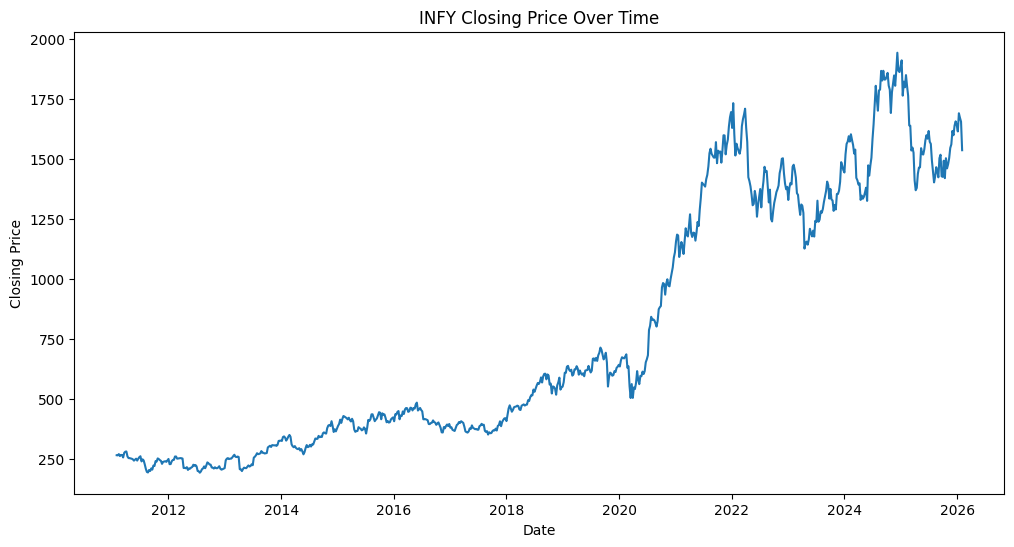

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("INFY Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

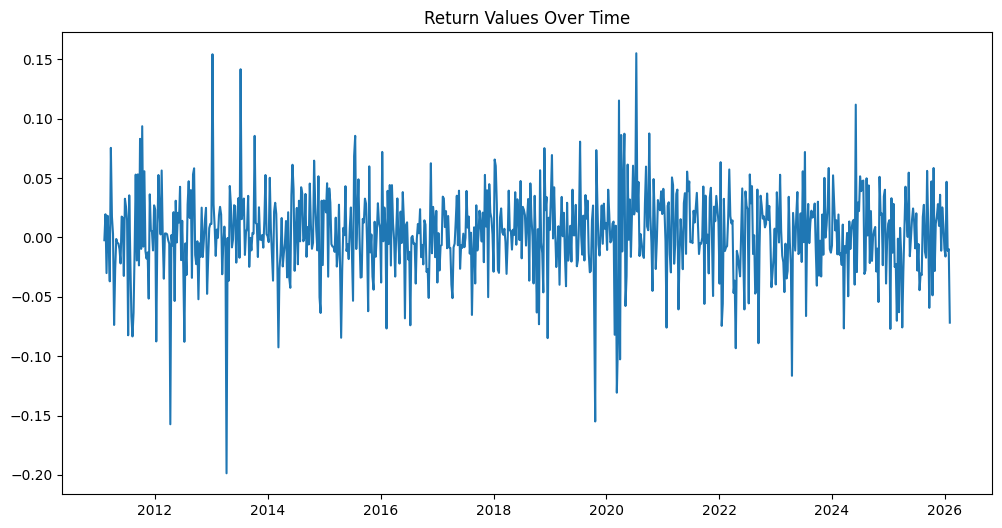

In [ ]:
df['Return'] = df['Close'].pct_change()

plt.figure(figsize=(12,6))
plt.plot(df['Return'])
plt.title("Return Values Over Time")
plt.show()

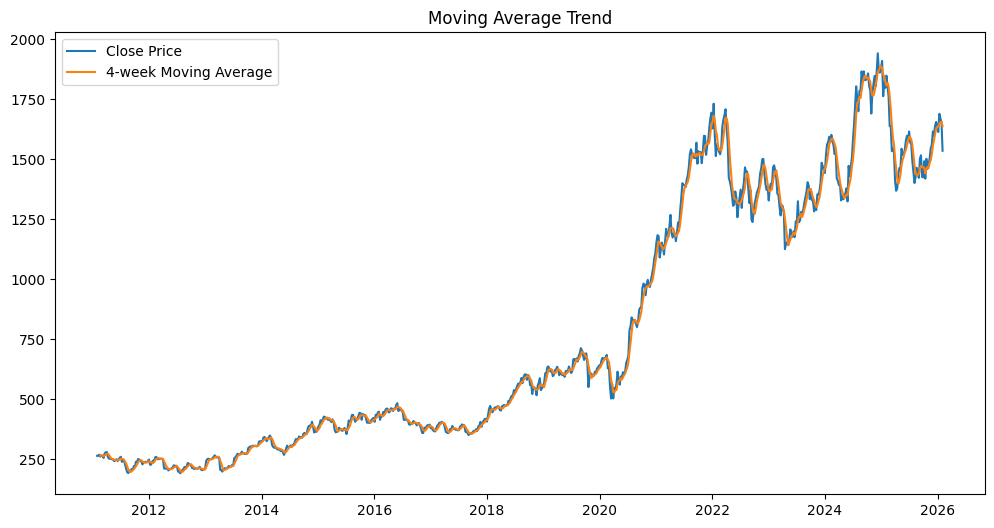

In [ ]:
df['MA_4'] = df['Close'].rolling(window=4).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA_4'], label='4-week Moving Average')
plt.legend()
plt.title("Moving Average Trend")
plt.show()

In [ ]:
# ============================================
# STEP 1: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [ ]:
# ============================================
# STEP 2: Load Dataset
# ============================================

df = pd.read_csv("/content/output_candle_INFY.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

data = df[['Close']].copy()

/tmp/ipython-input-2354692327.py:7: UserWarning:

Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [ ]:
# ============================================
# STEP 3: Train-Test Split
# ============================================

train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

In [ ]:
# ============================================
# STEP 4: Normalize Data
# ============================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [ ]:
# ============================================
# STEP 5: Create Sequences
# ============================================

window_size = 4

def create_sequences(dataset, window_size):

    X = []
    y = []

    for i in range(window_size, len(dataset)):
        X.append(dataset[i-window_size:i])
        y.append(dataset[i])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, window_size)

In [ ]:
# ============================================
# STEP 6: Build GRU Model
# ============================================

model = Sequential()

model.add(GRU(64, input_shape=(window_size, 1)))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# STEP 7: Train Model
# ============================================

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    verbose=1
)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4357e-04
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.4934e-04
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5000e-04
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6665e-04
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1371e-04
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3483e-04
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.6641e-04
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.8041e-04
Epoch 9/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5502e-04
Epoch 10/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1786e-04
Epoch 11/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3781e-04
Epoch 12/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.7215e-04
Epoch 13/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9679e-04
Epoch 14/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.8585e-04
Epoch 15/100
78

In [ ]:
# ============================================
# STEP 8: Walk-Forward Validation (CORRECT)
# ============================================

history = list(train_scaled)

walk_predictions = []
walk_actual = []

for i in range(len(test_scaled)):

    input_seq = np.array(history[-window_size:])
    input_seq = input_seq.reshape(1, window_size, 1)

    pred = model.predict(input_seq, verbose=0)[0][0]

    walk_predictions.append(pred)
    walk_actual.append(test_scaled[i][0])

    history.append(test_scaled[i])


# Convert back to original scale

walk_predictions = scaler.inverse_transform(
    np.array(walk_predictions).reshape(-1,1)
)

walk_actual = scaler.inverse_transform(
    np.array(walk_actual).reshape(-1,1)
)

In [ ]:
# ============================================
# STEP 9: Evaluation Metrics
# ============================================

mae = mean_absolute_error(walk_actual, walk_predictions)

rmse = np.sqrt(mean_squared_error(walk_actual, walk_predictions))

mape = np.mean(np.abs((walk_actual - walk_predictions) / walk_actual)) * 100

print("\nModel Performance:")
print("------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

accuracy = 100 - mape
print(f"Accuracy: {accuracy:.2f}%")


Model Performance:
------------------
MAE  : 43.1909
RMSE : 55.8884
MAPE : 2.91%
Accuracy: 97.09%


In [ ]:
# ============================================
# STEP 10: Next Week Forecast
# ============================================

last_sequence = scaler.transform(data[-window_size:])
last_sequence = last_sequence.reshape(1, window_size, 1)

next_week_scaled = model.predict(last_sequence, verbose=0)

next_week_price = scaler.inverse_transform(next_week_scaled)[0][0]

current_price = data['Close'].iloc[-1]

next_week_return = (next_week_price - current_price) / current_price

print("\nNext Week Forecast:")
print("-------------------")
print(f"Current Price        : {current_price:.2f}")
print(f"Predicted Price      : {next_week_price:.2f}")
print(f"Predicted Return     : {next_week_return:.4f}")
print(f"Predicted Return (%) : {next_week_return*100:.2f}%")


Next Week Forecast:
-------------------
Current Price        : 1535.80
Predicted Price      : 1549.79
Predicted Return     : 0.0091
Predicted Return (%) : 0.91%


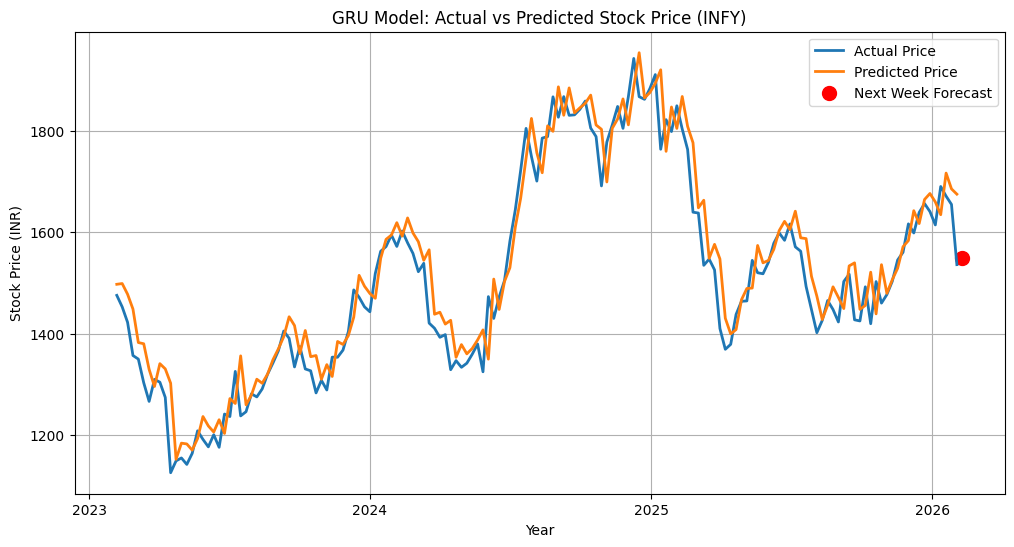

In [ ]:
# ============================================
# STEP 11: Correct Plot
# ============================================

aligned_dates = data.index[train_size : train_size + len(walk_predictions)]

plt.figure(figsize=(12,6))

plt.plot(aligned_dates, walk_actual.flatten(),
         label="Actual Price", linewidth=2)

plt.plot(aligned_dates, walk_predictions.flatten(),
         label="Predicted Price", linewidth=2)

# Next week point
next_date = data.index[-1] + pd.Timedelta(weeks=1)

plt.scatter(next_date,
            next_week_price,
            color='red',
            s=100,
            label="Next Week Forecast")

plt.title("GRU Model: Actual vs Predicted Stock Price (INFY)")
plt.xlabel("Year")
plt.ylabel("Stock Price (INR)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print(data.tail(10))

             Close
Date              
2025-12-01  1616.2
2025-12-08  1598.2
2025-12-15  1638.7
2025-12-22  1656.1
2025-12-29  1640.4
2026-01-05  1614.1
2026-01-12  1689.8
2026-01-19  1670.8
2026-01-26  1654.5
2026-02-02  1535.8


LSTM

/tmp/ipython-input-887/750712813.py:23: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_lstm['Date'] = pd.to_datetime(df_lstm['Date'])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0554
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.8766e-04
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.0826e-04
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.9241e-04
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.2026e-04
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9884e-04
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.3012e-04
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.4986e-04
Epoch 9/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6857e-04
Epoch 10/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0943e-04
Epoch 11/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6097e-04
Epoch 12/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.3618e-04
Epoch 13/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.7860e-04
Epoch 14/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.5918e-04
Epoch 15/100
78/78 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


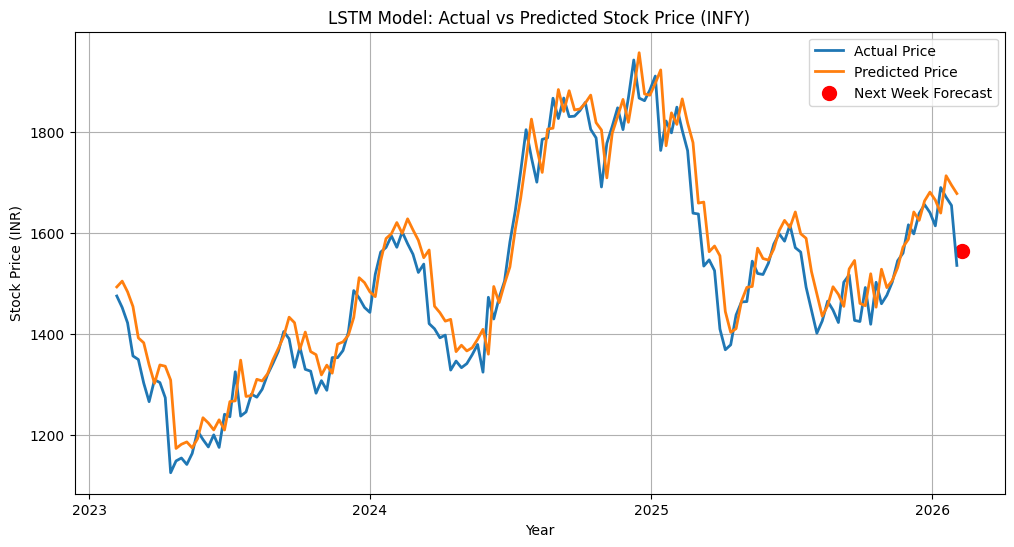

In [ ]:
# ============================================
# STEP 1: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# ============================================
# STEP 2: Load Dataset
# ============================================

df_lstm = pd.read_csv("output_candle_INFY.csv")

df_lstm['Date'] = pd.to_datetime(df_lstm['Date'])
df_lstm = df_lstm.sort_values('Date')
df_lstm.set_index('Date', inplace=True)

data = df_lstm[['Close']].copy()


# ============================================
# STEP 3: Train-Test Split
# ============================================

train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]


# ============================================
# STEP 4: Normalize Data
# ============================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)


# ============================================
# STEP 5: Create Sequences
# ============================================

window_size = 4

def create_sequences(dataset, window_size):

    X = []
    y = []

    for i in range(window_size, len(dataset)):
        X.append(dataset[i-window_size:i])
        y.append(dataset[i])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, window_size)


# ============================================
# STEP 6: Build LSTM Model
# ============================================

model = Sequential()

model.add(LSTM(
    units=64,
    input_shape=(window_size, 1)
))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()


# ============================================
# STEP 7: Train Model
# ============================================

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    verbose=1
)


# ============================================
# STEP 8: Walk-Forward Validation
# ============================================

history = list(train_scaled)

walk_predictions = []
walk_actual = []

for i in range(len(test_scaled)):

    input_seq = np.array(history[-window_size:])
    input_seq = input_seq.reshape(1, window_size, 1)

    pred = model.predict(input_seq, verbose=0)[0][0]

    walk_predictions.append(pred)
    walk_actual.append(test_scaled[i][0])

    history.append(test_scaled[i])


# Convert back to original scale

walk_predictions = scaler.inverse_transform(
    np.array(walk_predictions).reshape(-1,1)
)

walk_actual = scaler.inverse_transform(
    np.array(walk_actual).reshape(-1,1)
)


# ============================================
# STEP 9: Evaluation Metrics
# ============================================

mae = mean_absolute_error(walk_actual, walk_predictions)

rmse = np.sqrt(mean_squared_error(walk_actual, walk_predictions))

mape = np.mean(np.abs((walk_actual - walk_predictions) / walk_actual)) * 100

accuracy = 100 - mape

print("\nLSTM Model Performance:")
print("-----------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")


# ============================================
# STEP 10: Next Week Forecast
# ============================================

last_sequence = df_lstm[['Close']].iloc[-window_size:].values

last_sequence_scaled = scaler.transform(last_sequence)

last_sequence_scaled = last_sequence_scaled.reshape(1, window_size, 1)

next_week_scaled = model.predict(last_sequence_scaled, verbose=0)

next_week_price = scaler.inverse_transform(next_week_scaled)[0][0]

current_price = df_lstm['Close'].iloc[-1]

next_week_return = (next_week_price - current_price) / current_price

print("\nNext Week Forecast (LSTM):")
print("--------------------------")
print(f"Current Price        : {current_price:.2f}")
print(f"Predicted Price      : {next_week_price:.2f}")
print(f"Predicted Return (%) : {next_week_return*100:.2f}%")


# ============================================
# STEP 11: Plot Results
# ============================================

aligned_dates = df_lstm.index[train_size : train_size + len(walk_predictions)]

plt.figure(figsize=(12,6))

plt.plot(aligned_dates,
         walk_actual.flatten(),
         label="Actual Price",
         linewidth=2)

plt.plot(aligned_dates,
         walk_predictions.flatten(),
         label="Predicted Price",
         linewidth=2)

# Next week forecast point
next_date = df_lstm.index[-1] + pd.Timedelta(weeks=1)

plt.scatter(next_date,
            next_week_price,
            color='red',
            s=100,
            label="Next Week Forecast")

plt.title("LSTM Model: Actual vs Predicted Stock Price (INFY)")
plt.xlabel("Year")
plt.ylabel("Stock Price (INR)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.grid(True)

plt.show()

CNN-LSTM

/tmp/ipython-input-887/233706791.py:23: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_cnn_lstm['Date'] = pd.to_datetime(df_cnn_lstm['Date'])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 3, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,281 (130.00 KB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0312
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.4611e-04
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.4864e-04
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.7705e-04
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6686e-04
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.7134e-04
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.0206e-04
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.8894e-04
Epoch 9/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4176e-04
Epoch 10/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4640e-04
Epoch 11/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.6278e-04
Epoch 12/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.1159e-04
Epoch 13/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.1824e-04
Epoch 14/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.6091e-04
Epoch 15/100
78/78 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


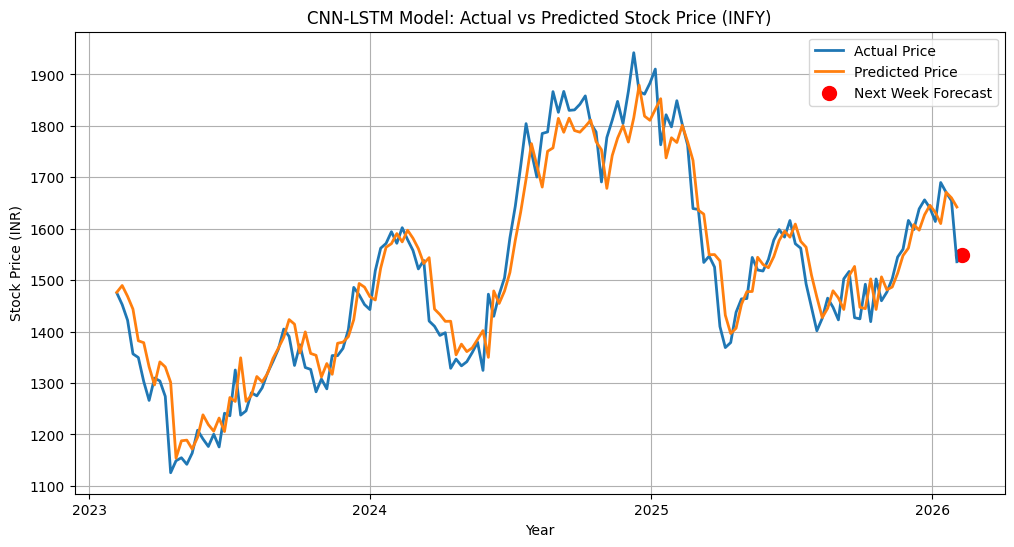

In [ ]:
# ============================================
# STEP 1: Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Flatten


# ============================================
# STEP 2: Load Dataset
# ============================================

df_cnn_lstm = pd.read_csv("/content/output_candle_INFY.csv")

df_cnn_lstm['Date'] = pd.to_datetime(df_cnn_lstm['Date'])
df_cnn_lstm = df_cnn_lstm.sort_values('Date')
df_cnn_lstm.set_index('Date', inplace=True)

data = df_cnn_lstm[['Close']].copy()


# ============================================
# STEP 3: Train-Test Split
# ============================================

train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]


# ============================================
# STEP 4: Normalize Data
# ============================================

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)


# ============================================
# STEP 5: Create Sequences
# ============================================

window_size = 4

def create_sequences(dataset, window_size):

    X = []
    y = []

    for i in range(window_size, len(dataset)):
        X.append(dataset[i-window_size:i])
        y.append(dataset[i])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, window_size)


# ============================================
# STEP 6: Build CNN-LSTM Model
# ============================================

model = Sequential()

# CNN layer
model.add(Conv1D(
    filters=64,
    kernel_size=2,
    activation='relu',
    input_shape=(window_size, 1)
))

# LSTM layer
model.add(LSTM(64))

# Output layer
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()


# ============================================
# STEP 7: Train Model
# ============================================

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    verbose=1
)


# ============================================
# STEP 8: Walk-Forward Validation
# ============================================

history = list(train_scaled)

walk_predictions = []
walk_actual = []

for i in range(len(test_scaled)):

    input_seq = np.array(history[-window_size:])
    input_seq = input_seq.reshape(1, window_size, 1)

    pred = model.predict(input_seq, verbose=0)[0][0]

    walk_predictions.append(pred)
    walk_actual.append(test_scaled[i][0])

    history.append(test_scaled[i])


# Convert back to original scale

walk_predictions = scaler.inverse_transform(
    np.array(walk_predictions).reshape(-1,1)
)

walk_actual = scaler.inverse_transform(
    np.array(walk_actual).reshape(-1,1)
)


# ============================================
# STEP 9: Evaluation Metrics
# ============================================

mae = mean_absolute_error(walk_actual, walk_predictions)

rmse = np.sqrt(mean_squared_error(walk_actual, walk_predictions))

mape = np.mean(np.abs((walk_actual - walk_predictions) / walk_actual)) * 100

accuracy = 100 - mape

print("\nCNN-LSTM Model Performance:")
print("---------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")


# ============================================
# STEP 10: Next Week Forecast
# ============================================

last_sequence = df_cnn_lstm[['Close']].iloc[-window_size:].values

last_sequence_scaled = scaler.transform(last_sequence)

last_sequence_scaled = last_sequence_scaled.reshape(1, window_size, 1)

next_week_scaled = model.predict(last_sequence_scaled, verbose=0)

next_week_price = scaler.inverse_transform(next_week_scaled)[0][0]

current_price = df_cnn_lstm['Close'].iloc[-1]

next_week_return = (next_week_price - current_price) / current_price

print("\nNext Week Forecast (CNN-LSTM):")
print("------------------------------")
print(f"Current Price        : {current_price:.2f}")
print(f"Predicted Price      : {next_week_price:.2f}")
print(f"Predicted Return (%) : {next_week_return*100:.2f}%")


# ============================================
# STEP 11: Plot Results
# ============================================

aligned_dates = df_cnn_lstm.index[train_size : train_size + len(walk_predictions)]

plt.figure(figsize=(12,6))

plt.plot(aligned_dates,
         walk_actual.flatten(),
         label="Actual Price",
         linewidth=2)

plt.plot(aligned_dates,
         walk_predictions.flatten(),
         label="Predicted Price",
         linewidth=2)

# Next week forecast point
next_date = df_cnn_lstm.index[-1] + pd.Timedelta(weeks=1)

plt.scatter(next_date,
            next_week_price,
            color='red',
            s=100,
            label="Next Week Forecast")

plt.title("CNN-LSTM Model: Actual vs Predicted Stock Price (INFY)")
plt.xlabel("Year")
plt.ylabel("Stock Price (INR)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.grid(True)

plt.show()